# Supplemental Figure: Methodology Illustration at a Single Site

This notebook produces the supplemental figure showing step-by-step how:
1. Snow pillow runoff onset is derived from the SWE time series (95% of water-year maximum)
2. SAR runoff onset is derived from the C-band backscatter minimum
3. How the two compare — for both a **clear** year and an **ambiguous** year

This directly addresses reviewer concerns about methodology transparency before scaling to all sites.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import xarray as xr
import geopandas as gpd
import rasterio
import easysnowdata
from global_snowmelt_runoff_onset.config import Config
import global_snowmelt_runoff_onset.processing as processing
import warnings
warnings.filterwarnings('ignore')

## Configuration and Data Loading

In [2]:
from pathlib import Path

config = Config('config/global_config_v9.txt')

# Figures and the input comparison dataset are scoped by dataset version so a v10
# run cannot overwrite the v9 figures. Switching versions = editing the path above.
VERSION = config.version
FIGURE_DIR = Path('figures') / VERSION
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
COMPARISON_NC = Path('comparison_datasets') / f'snotel_sar_differences_UPDATED_SNOTEL_LOCATIONS_andreq10cmSWEfor60days_{VERSION}.nc'

buffer_radius = 1000
fcf_thresh    = 50

SAS token is valid until 2026-07-03 00:51 UTC (174.9 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [3]:
StationsWUS = easysnowdata.automatic_weather_stations.StationCollection()
StationsWUS.get_entire_data_archive()

stations_WUS_raw_da = StationsWUS.entire_data_archive['WTEQ'].sel(
    time=slice('2014-10-01', '2024-09-30')
)

Geodataframe with all stations has been added to the Station object. Please use the .all_stations attribute to access.
Use the .get_data(stations=geodataframe/string/list,variables=string/list,start_date=str,end_date=str) method to fetch data for specific stations and variables.
Decompressing data...
Creating xarray.Dataset from the uncompressed data...
Done! Entire archive dataset has been added to the station object. Please use the .entire_data_archive attribute to access.


In [4]:
# ── Reproduce the same filtering pipeline from the manuscript ──
stations_WUS_da = stations_WUS_raw_da.where(stations_WUS_raw_da >= 0)

abs_diffs         = np.abs(stations_WUS_da.diff(dim='time'))
abs_diffs_forward = abs_diffs.shift(time=1)
abs_diffs_back    = abs_diffs.shift(time=-1)
jump_mask         = (abs_diffs_forward < 0.2) & (abs_diffs_back < 0.2)
stations_WUS_da   = stations_WUS_da.where(jump_mask)

window = 10
valid_mask    = ~np.isnan(stations_WUS_da)
rolling_valid = valid_mask.rolling(time=window * 2, center=True).sum()
stations_WUS_da = stations_WUS_da.where(rolling_valid >= window)

# Missing-data and seasonal-snow checks (same as main analysis)
def check_missing_data(group):
    nov_to_apr_mask      = group.time.dt.month.isin([11, 12, 1, 2, 3])
    filtered_group       = group.where(nov_to_apr_mask, drop=True)
    missing_data_counts  = filtered_group.isnull().sum(dim='time')
    missing_data         = missing_data_counts > 30
    valid_data           = ~np.isnan(group)

    def calc_location_gaps(location_data):
        valid_indices = ~np.isnan(location_data)
        if not np.any(valid_indices):
            return True
        valid_times = group.time.values[valid_indices]
        gaps = np.diff(valid_times)
        return np.any(gaps / np.timedelta64(1, 'D') > 10)

    large_gaps = xr.apply_ufunc(
        calc_location_gaps, group,
        input_core_dims=[['time']], vectorize=True, output_dtypes=[bool]
    )

    if valid_data.any():
        first_valid_idx = valid_data.argmax(dim='time')
        last_valid_idx  = valid_data[:, ::-1].argmax(dim='time')
        first_valid     = group.isel(time=first_valid_idx)
        last_valid      = group.isel(time=group.sizes['time'] - last_valid_idx - 1)
        improper_evolution = (first_valid > 0.1) | (last_valid > 0.1)
    else:
        improper_evolution = True

    columns_to_nan = missing_data | large_gaps | improper_evolution
    group[columns_to_nan] = np.nan
    return group

def check_seasonal_snow_swe(group):
    sufficient_swe  = (group >= 0.05).rolling(time=60, center=True, min_periods=55).sum()
    columns_to_keep = (sufficient_swe >= 55).any(dim='time')
    group[~columns_to_keep] = np.nan
    return group

stations_WUS_da = stations_WUS_da.groupby('WY').apply(check_missing_data)
stations_WUS_da = stations_WUS_da.groupby('WY').apply(check_seasonal_snow_swe)
stations_WUS_da

<xarray.DataArray 'WTEQ' (station: 969, time: 3652)> Size: 28MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(969, 3652))
Coordinates: (12/17)
  * time           (time) datetime64[ns] 29kB 2014-10-02 ... 2024-09-30
  * station        (station) <U12 47kB '1135_UT_SNTL' ... '915_ID_SNTL'
    name           (station) <U24 93kB 'Burts Miller Ranch' ... 'Schwartz Lake'
    network        (station) <U6 23kB 'SNOTEL' 'SNOTEL' ... 'SNOTEL' 'SNOTEL'
    elevation_m    (station) float64 8kB 2.438e+03 2.377e+03 ... 2.63e+03
    latitude       (station) float64 8kB 40.98 44.79 37.16 ... 40.28 42.3 44.85
    ...             ...
    beginDate      (station) datetime64[ns] 8kB 2009-10-01 ... 1995-09-26
    endDate        (station) datetime64[ns] 8kB 2026-06-24 ... 2026-06-24
    csvData        (station) bool 969B True True True True ... True True True
    geometry       (station) object 8kB POINT (-110.85075378417969 40.9849205...
    WY             (time) int64 29kB 2015 2015 2015 2015 ... 2024 2024 2024 2024
    DOWY           (time) int64 29kB 2 3 4 5 6 7 8 ... 361 362 363 364 365 366

In [5]:
# ── Pre-computed comparison dataset (snow pillow onset + SAR onset per WY) ──
runoff_onset_ds = xr.open_dataset(COMPARISON_NC).compute()
runoff_onset_ds

<xarray.Dataset> Size: 12MB
Dimensions:                       (station: 969, WY: 10, buffer_radius: 4,
                                   fcf: 10)
Coordinates: (12/16)
  * station                       (station) <U12 47kB '1135_UT_SNTL' ... '915...
    name                          (station) <U24 93kB 'Burts Miller Ranch' .....
    network                       (station) <U6 23kB 'SNOTEL' ... 'SNOTEL'
    elevation_m                   (station) float64 8kB 2.438e+03 ... 2.63e+03
    latitude                      (station) float64 8kB 40.98 44.79 ... 44.85
    longitude                     (station) float64 8kB -110.9 -112.1 ... -113.8
    ...                            ...
    beginDate                     (station) datetime64[ns] 8kB 2009-10-01 ......
    endDate                       (station) datetime64[ns] 8kB 2025-07-13 ......
    csvData                       (station) bool 969B True True ... True True
  * WY                            (WY) int64 80B 2015 2016 2017 ... 2023 2024
  * buffer_radius                 (buffer_radius) int64 32B 100 300 500 1000
  * fcf                           (fcf) int64 80B 10 20 30 40 50 60 70 80 90 100
Data variables: (12/15)
    station_max_SWE_timing        (station, WY) float32 39kB nan 186.0 ... 193.0
    station_max_SWE_value         (station, WY) float32 39kB nan ... 0.2769
    station_max_SWE_99pct_timing  (station, WY) float32 39kB nan 186.0 ... 194.0
    station_max_SWE_95pct_timing  (station, WY) float32 39kB nan 186.0 ... 196.0
    station_max_SWE_90pct_timing  (station, WY) float32 39kB nan 186.0 ... 197.0
    station_max_SWE_50pct_timing  (station, WY) float32 39kB nan 190.0 ... 226.0
    ...                            ...
    mean_fcf                      (station, buffer_radius, fcf) float32 155kB ...
    sar_minus_stations            (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_99pct               (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_95pct               (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_90pct               (station, WY, buffer_radius, fcf) float32 2MB ...
    sar_minus_50pct               (station, WY, buffer_radius, fcf) float32 2MB ...

In [6]:
# ── Pull the relevant slice from the precomputed dataset ──────────────────────
ds_sel = runoff_onset_ds.sel(fcf=fcf_thresh, buffer_radius=buffer_radius)

# Convert to a tidy DataFrame: one row per (station, WY)
df = ds_sel[['sar_minus_95pct', 'station_max_SWE_95pct_timing', 'mean_fcf', 'frac_valid_fcf']].to_dataframe().reset_index()


swe_var = [v for v in ds_sel.data_vars if 'max' in v.lower() and 'swe' in v.lower() and 'timing' not in v.lower()]
print('SWE magnitude variables found:', swe_var)

if swe_var:
    df['max_SWE'] = ds_sel[swe_var[0]].values.ravel()[:len(df)]
    df['max_SWE'] = ds_sel[swe_var[0]].to_dataframe().reset_index()['station_max_SWE_value'] # adjust col name as needed

df['abs_diff'] = np.abs(df['sar_minus_95pct'])
df = df.dropna(subset=['sar_minus_95pct', 'max_SWE'])

# ── For each station: correlate max SWE with agreement quality ────────────────
# A station is a good candidate if:
#   1. Pearson r between max_SWE and -abs_diff is positive (more snow → better agreement)
#   2. It has at least `min_years` valid paired observations
#   3. The median abs_diff across all years is reasonable (not a systematically bad site)
#   4. There is meaningful SWE variability across years (so high vs low years are distinct)

min_years       = 5     # minimum number of valid WYs required
max_median_diff = 20    # days — exclude chronically bad stations
min_swe_range   = 0.20  # metres — station must have real interannual SWE variability
max_low_swe=0.3

records = []
for station, grp in df.groupby('station'):
    grp = grp.dropna(subset=['max_SWE', 'abs_diff'])
    if len(grp) < min_years:
        continue
    if grp['abs_diff'].median() > max_median_diff:
        continue
    swe_range = grp['max_SWE'].max() - grp['max_SWE'].min()
    if swe_range < min_swe_range:
        continue


    r = grp[['max_SWE', 'abs_diff']].corr().loc['max_SWE', 'abs_diff']

    # Best high-SWE year = best agreement (lowest abs_diff among top-SWE years)
    top_swe_years    = grp.nlargest(3, 'max_SWE')
    best_high_row    = top_swe_years.nsmallest(1, 'abs_diff').iloc[0]

    # Best low-SWE year = moderate disagreement (abs_diff in 10–30 day range)
    low_swe_years    = grp.nsmallest(3, 'max_SWE')
    moderate_diff    = low_swe_years[(low_swe_years['abs_diff'] >= 8) &
                                     (low_swe_years['abs_diff'] <= 30) &
                                     (low_swe_years['max_SWE'] <= max_low_swe)]

    if moderate_diff.empty:
        continue
    best_low_row = moderate_diff.nsmallest(1, 'max_SWE').iloc[0]

    records.append(dict(
        station=station,
        n_years=len(grp),
        swe_range_m=round(swe_range, 3),
        corr_swe_vs_absdiff=round(r, 3),   # negative = more snow → better agreement
        median_abs_diff=round(grp['abs_diff'].median(), 1),
        high_swe_WY=int(best_high_row['WY']),
        high_swe_m=round(best_high_row['max_SWE'], 3),
        high_swe_diff_days=round(best_high_row['abs_diff'], 1),
        low_swe_WY=int(best_low_row['WY']),
        low_swe_m=round(best_low_row['max_SWE'], 3),
        low_swe_diff_days=round(best_low_row['abs_diff'], 1),
    ))

candidates = (
    pd.DataFrame(records)
    .set_index('station')
    .sort_values('corr_swe_vs_absdiff')   # most negative r first = strongest pattern
)


print(f'{len(candidates)} candidate stations found.\n')
candidates.head(50)

SWE magnitude variables found: ['station_max_SWE_value']
249 candidate stations found.



,n_years,swe_range_m,corr_swe_vs_absdiff,median_abs_diff,high_swe_WY,high_swe_m,high_swe_diff_days,low_swe_WY,low_swe_m,low_swe_diff_days
station,,,,,,,,,,
1097_UT_SNTL,5,0.412,-0.957,6.0,2023,0.648,0.0,2022,0.236,10.0
811_NV_SNTL,6,0.307,-0.900,12.0,2023,0.439,3.0,2022,0.132,25.0
330_UT_SNTL,8,0.381,-0.829,8.5,2017,0.531,2.0,2018,0.178,17.0
749_ID_SNTL,8,0.257,-0.821,9.0,2017,0.437,2.0,2018,0.262,15.0
1017_NM_SNTL,8,0.218,-0.819,11.0,2023,0.455,0.0,2022,0.236,12.0
320_ID_SNTL,6,0.414,-0.794,10.5,2017,0.643,2.0,2021,0.229,10.0
1116_UT_SNTL,5,0.257,-0.788,9.0,2023,0.434,1.0,2022,0.178,9.0
1277_CA_SNTL,7,0.462,-0.786,10.0,2017,0.467,1.0,2020,0.168,29.0
1149_UT_SNTL,7,0.201,-0.766,14.0,2020,0.343,1.0,2017,0.244,26.0


In [7]:

# ── Visualise the pattern at the top candidate ────────────────────────────────
top_station = '846_CA_SNTL'#'728_WA_SNTL'#'1017_NM_SNTL'#'578_MT_SNTL'#'1100_CO_SNTL'#'749_ID_SNTL'#'1077_OR_SNTL'#candidates.index[0]
top_station = "330_UT_SNTL"
top_station="679_WA_SNTL"
top         = candidates.loc[top_station]

grp = df[df['station'] == top_station].sort_values('max_SWE')

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(grp['max_SWE'], grp['abs_diff'],
                c=grp['WY'], cmap='viridis', s=80, zorder=3)

# Annotate each point with its water year
for _, row in grp.iterrows():
    ax.text(row['max_SWE'] + 0.005, row['abs_diff'] + 0.3,
            str(int(row['WY'])), fontsize=8, color='#333333')

# Highlight the two chosen years
for wy_key, color, label in [
    (top['high_swe_WY'], '#2166ac', 'Clear year (high SWE)'),
    (top['low_swe_WY'],  '#d73027', 'Ambiguous year (low SWE)')
]:
    row = grp[grp['WY'] == wy_key].iloc[0]
    ax.scatter(row['max_SWE'], row['abs_diff'],
               s=180, color=color, zorder=5, label=label,
               edgecolors='black', linewidths=1.2)

ax.set_xlabel('Water-year maximum SWE (m)', fontsize=11)
ax.set_ylabel('|SAR onset − snow pillow onset|  (days)', fontsize=11)
ax.set_title(f'{top_station}\nr = {top["corr_swe_vs_absdiff"]:.2f}  |  median diff = {top["median_abs_diff"]} days',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n>>> Suggested settings for the supplemental figure:")
print(f"    station_code  = '{top_station}'")
print(f"    clear_wy      = {int(top['high_swe_WY'])}   # max SWE = {top['high_swe_m']} m, diff = {top['high_swe_diff_days']} days")
print(f"    ambiguous_wy  = {int(top['low_swe_WY'])}   # max SWE = {top['low_swe_m']} m, diff = {top['low_swe_diff_days']} days")

KeyError: '679_WA_SNTL'

In [8]:
# ── USER SETTINGS ──────────────────────────────────────────────────────────────
# Choose a station that has a clear and an ambiguous year available.
# Swap station_code and water years to regenerate for a different site.

# ----MANUSCRIPT VERSION-------
station_code  = '846_CA_SNTL'#'728_WA_SNTL'#'578_MT_SNTL'#'1100_CO_SNTL'#'749_ID_SNTL'#'1077_OR_SNTL'#'675_CO_SNTL'   # example — change as desired
clear_wy     = 2017#2018#2023#2023#2017#2019   # year with a clean, unambiguous signal in both datasets
ambiguous_wy = 2021#2022#2017#2018#2018#2015   # year with mid-season melt, noise, or broad SAR minimum
# ---------------------------------


station_code = '330_UT_SNTL'#'846_CA_SNTL'#'728_WA_SNTL'#'578_MT_SNTL'#'1100_CO_SNTL'#'749_ID_SNTL'#'1077_OR_SNTL'#'675_CO_SNTL'   # example — change as desired
clear_wy=2017
ambiguous_wy=2018

station_code = '679_WA_SNTL'#'846_CA_SNTL'#'728_WA_SNTL'#'578_MT_SNTL'#'1100_CO_SNTL'#'749_ID_SNTL'#'1077_OR_SNTL'#'675_CO_SNTL'   # example — change as desired
clear_wy=2023
ambiguous_wy=2020
# ───────────────────────────────────────────────────────────────────────────────

In [9]:
station_ds = runoff_onset_ds.sel(
    station=station_code,
    buffer_radius=buffer_radius,
    fcf=fcf_thresh
)
station_ds

<xarray.Dataset> Size: 1kB
Dimensions:                       (WY: 10)
Coordinates: (12/16)
    station                       <U12 48B '679_WA_SNTL'
    name                          <U24 96B 'Paradise'
    network                       <U6 24B 'SNOTEL'
    elevation_m                   float64 8B 1.564e+03
    latitude                      float64 8B 46.78
    longitude                     float64 8B -121.7
    ...                            ...
    beginDate                     datetime64[ns] 8B 1979-10-01
    endDate                       datetime64[ns] 8B 2025-07-13
    csvData                       bool 1B True
  * WY                            (WY) int64 80B 2015 2016 2017 ... 2023 2024
    buffer_radius                 int64 8B 1000
    fcf                           int64 8B 50
Data variables: (12/15)
    station_max_SWE_timing        (WY) float32 40B 198.0 202.0 ... 211.0 223.0
    station_max_SWE_value         (WY) float32 40B 0.6909 1.986 ... 1.905 1.549
    station_max_SWE_99pct_timing  (WY) float32 40B 199.0 202.0 ... 215.0 224.0
    station_max_SWE_95pct_timing  (WY) float32 40B 210.0 215.0 ... 216.0 227.0
    station_max_SWE_90pct_timing  (WY) float32 40B 213.0 218.0 ... 226.0 237.0
    station_max_SWE_50pct_timing  (WY) float32 40B 231.0 249.0 ... 249.0 267.0
    ...                            ...
    mean_fcf                      float32 4B 30.02
    sar_minus_stations            (WY) float32 40B -10.0 -9.0 ... -10.0 -36.0
    sar_minus_99pct               (WY) float32 40B -11.0 -9.0 ... -14.0 -37.0
    sar_minus_95pct               (WY) float32 40B -22.0 -22.0 ... -15.0 -40.0
    sar_minus_90pct               (WY) float32 40B -25.0 -25.0 ... -25.0 -50.0
    sar_minus_50pct               (WY) float32 40B -43.0 -56.0 ... -48.0 -80.0

In [10]:
# Keep raw SWE for a single station (used to show unfiltered signal)
raw_swe = stations_WUS_raw_da.sel(station=station_code).where(
    stations_WUS_raw_da.sel(station=station_code) >= 0
)

filtered_swe = stations_WUS_da.sel(station=station_code)

In [11]:
# ── Station location geometry (for clipping SAR data) ──
stations_gdf = gpd.read_file(
    '~/repos/updated_snotel_locations/snotel_stations_with_updated_locations.geojson'
).set_index('code')

def get_station_gdf(stations_gdf, station_code, buffer_radius=None):
    station_gdf   = stations_gdf[stations_gdf.index == station_code]
    station_epsg  = station_gdf.estimate_utm_crs().to_epsg()
    station_gdf   = station_gdf.to_crs(epsg=station_epsg)
    if buffer_radius:
        station_gdf['geometry'] = station_gdf.geometry.buffer(buffer_radius)
    return station_gdf

station_gdf = get_station_gdf(stations_gdf, station_code, buffer_radius)

In [12]:
# ── Sentinel-1 C-band SAR backscatter (VV) ──
runoff_onset_global_ds   = config.open_runoff_onset_dataset()
runoff_onset_station_ds  = runoff_onset_global_ds.rio.clip_box(
    *station_gdf.total_bounds, crs=station_gdf.crs
).rio.reproject(station_gdf.crs)

s1_rtc_ds       = processing.get_sentinel1_rtc(runoff_onset_station_ds.odc.geobox)
backscatter_da   = s1_rtc_ds.median(dim=['x', 'y']).compute()
backscatter_dB   = 10 * np.log10(backscatter_da)
vv_dB            = backscatter_dB['vv']
print('SAR data loaded.')

SAR data loaded.


## Helper functions

In [13]:
def wy_slice(wy):
    """Return a time-slice string tuple for a water year."""
    return f'{wy-1}-10-01', f'{wy}-09-30'


def get_swe_for_wy(da, wy):
    """Return SWE DataArray for a single water year."""
    return da.sel(time=slice(*wy_slice(wy)))


def compute_snow_pillow_onset(swe_da):
    """
    Replicate the manuscript method:
    Last day when SWE >= 95% of the water-year maximum.

    Returns
    -------
    onset_date  : pd.Timestamp or None
    max_swe     : float  (m)
    threshold   : float  (m)
    """
    swe_vals = swe_da.values
    times    = pd.to_datetime(swe_da.time.values)

    if np.all(np.isnan(swe_vals)):
        return None, np.nan, np.nan

    max_swe   = np.nanmax(swe_vals)
    threshold = 0.95 * max_swe

    # Last index where SWE is still at or above the threshold
    above = np.where(swe_vals >= threshold)[0]
    if len(above) == 0:
        return None, max_swe, threshold

    last_idx    = above[-1]
    onset_date  = times[last_idx]
    return onset_date, max_swe, threshold


def get_sar_for_wy(vv_dB, wy):
    """Return VV backscatter for a single water year, one series per relative orbit."""
    start, end = wy_slice(wy)
    wy_mask    = (pd.to_datetime(vv_dB.time.values) >= pd.Timestamp(start)) & \
                 (pd.to_datetime(vv_dB.time.values) <= pd.Timestamp(end))
    return vv_dB.isel(time=wy_mask)


def compute_sar_onset(vv_wy_da):
    """
    Derive the SAR runoff onset date as the date of the minimum VV backscatter
    within the water year, averaged across all relative orbits.

    Returns
    -------
    onset_date : pd.Timestamp or None
    min_dB     : float
    """
    times  = pd.to_datetime(vv_wy_da.time.values)
    vals   = vv_wy_da.values

    if np.all(np.isnan(vals)):
        return None, np.nan

    min_idx    = np.nanargmin(vals)
    onset_date = times[min_idx]
    min_dB     = vals[min_idx]
    return onset_date, min_dB


def dowy_to_date(dowy, wy):
    """Convert a day-of-water-year integer to a calendar date."""
    wy_start = pd.Timestamp(year=wy - 1, month=10, day=1)
    return wy_start + pd.Timedelta(days=int(dowy) - 1)

## Compute onset dates for the two chosen water years

In [14]:
results = {}

for wy, label in [(clear_wy, 'clear'), (ambiguous_wy, 'ambiguous')]:
    swe_wy = get_swe_for_wy(filtered_swe, wy)
    raw_wy = get_swe_for_wy(raw_swe,      wy)
    vv_wy  = get_sar_for_wy(vv_dB,        wy)

    sp_onset, max_swe, threshold = compute_snow_pillow_onset(swe_wy)
    sar_onset, min_dB            = compute_sar_onset(vv_wy)

    diff_days = None
    if sp_onset is not None and sar_onset is not None:
        diff_days = (sar_onset - sp_onset).days

    results[label] = dict(
        wy=wy, swe_wy=swe_wy, raw_wy=raw_wy, vv_wy=vv_wy,
        sp_onset=sp_onset, max_swe=max_swe, threshold=threshold,
        sar_onset=sar_onset, min_dB=min_dB,
        diff_days=diff_days
    )

    print(f"WY {wy} ({label}):")
    print(f"  Snow pillow onset : {sp_onset}  (SWE max={max_swe:.3f} m, threshold={threshold:.3f} m)")
    print(f"  SAR onset         : {sar_onset}  (min VV = {min_dB:.2f} dB)")
    print(f"  Difference        : {diff_days} days (SAR minus snow pillow)\n")

WY 2023 (clear):
  Snow pillow onset : 2023-05-04 00:00:00  (SWE max=1.905 m, threshold=1.810 m)
  SAR onset         : 2023-01-16 14:22:26.380524  (min VV = -10.44 dB)
  Difference        : -108 days (SAR minus snow pillow)

WY 2020 (ambiguous):
  Snow pillow onset : 2020-05-11 00:00:00  (SWE max=2.286 m, threshold=2.172 m)
  SAR onset         : 2020-03-02 14:21:19.948205  (min VV = -10.25 dB)
  Difference        : -70 days (SAR minus snow pillow)



## Build the supplemental figure

Layout: **2 columns × 3 rows**
- Column 1 = clear year, Column 2 = ambiguous year
- Row 1 = Snow pillow SWE (raw + filtered, 95% threshold, onset marked)
- Row 2 = C-band SAR VV backscatter per orbit (minimum / onset marked)
- Row 3 = Timeline comparison (both onset dates, difference labelled)

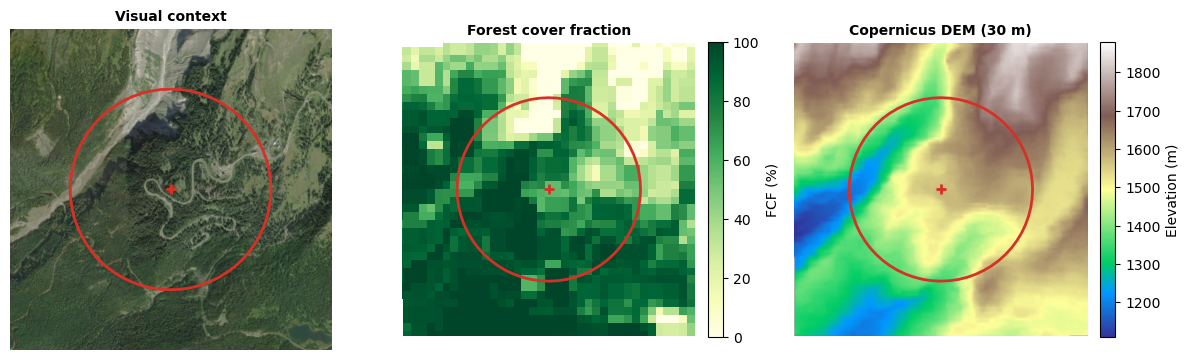

In [15]:
import matplotlib.pyplot as plt
import contextily as ctx
import rioxarray as rxr
import pystac_client
import planetary_computer
import odc.stac
import geopandas as gpd
from shapely.geometry import box

COL_SP = '#d73027'

# ── Use local UTM as the working CRS (equal area at local scale) ──────────────
utm_crs    = station_gdf.estimate_utm_crs()
station_utm = station_gdf.to_crs(utm_crs)
centroid    = station_utm.geometry.centroid

# ── Compute zoomed square extent in UTM ───────────────────────────────────────
def get_zoomed_extent(station_utm, zoom_factor=1.6):
    minx, miny, maxx, maxy = station_utm.total_bounds
    cx   = (minx + maxx) / 2
    cy   = (miny + maxy) / 2
    half = max((maxx - minx), (maxy - miny)) / 2 * zoom_factor
    return cx - half, cy - half, cx + half, cy + half

ext = get_zoomed_extent(station_utm, zoom_factor=1.6)

# Build zoomed bbox in 4326 for raster fetching
zoomed_box_utm  = gpd.GeoDataFrame(geometry=[box(*ext)], crs=utm_crs)
zoomed_box_4326 = zoomed_box_utm.to_crs('EPSG:4326')

# ── Load FCF reprojected to UTM ───────────────────────────────────────────────
def load_fcf(zoomed_box_4326, utm_crs):
    fcf_da = rxr.open_rasterio(
        "https://zenodo.org/record/3939050/files/PROBAV_LC100_global_v3.0.1_2019-nrt_Tree-CoverFraction-layer_EPSG-4326.tif",
        chunks=True, mask_and_scale=True,
    )
    fcf_da = fcf_da.rio.clip_box(*zoomed_box_4326.total_bounds, crs='EPSG:4326').squeeze()
    return fcf_da.rio.reproject(utm_crs).compute()

# ── Load DEM reprojected to UTM ───────────────────────────────────────────────
def load_dem(zoomed_box_4326, utm_crs, resolution=30):
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace
    )
    search = catalog.search(
        collections=[f"cop-dem-glo-{resolution}"],
        bbox=zoomed_box_4326.total_bounds
    )
    dem_da = odc.stac.load(
        search.items(), bbox=zoomed_box_4326.total_bounds, chunks={}
    )['data'].squeeze()
    dem_da = dem_da.rio.write_nodata(-32767, encoded=True)
    return dem_da.rio.reproject(utm_crs).compute()

fcf_utm = load_fcf(zoomed_box_4326, utm_crs)
dem_utm = load_dem(zoomed_box_4326, utm_crs)

# ── Shared helpers ────────────────────────────────────────────────────────────
def apply_shared_extent(ax):
    ax.set_xlim(ext[0], ext[2])
    ax.set_ylim(ext[1], ext[3])
    ax.set_aspect('equal')
    ax.set_axis_off()

def overlay_buffer(ax):
    station_utm.boundary.plot(ax=ax, color=COL_SP, linewidth=2, zorder=5)
    ax.scatter(centroid.x, centroid.y, color=COL_SP, s=60,
               zorder=6, marker='+', linewidths=2)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
ax_sat, ax_fcf, ax_dem = axes

# Satellite — contextily accepts crs kwarg for non-3857 axes
overlay_buffer(ax_sat)
apply_shared_extent(ax_sat)
ctx.add_basemap(ax_sat, crs=utm_crs.to_string(),
                source=ctx.providers.Esri.WorldImagery,
                zoom='auto', attribution=False)

# FCF
xc = fcf_utm.x.values
yc = fcf_utm.y.values
im_fcf = ax_fcf.imshow(
    fcf_utm.values, origin='upper',
    extent=[xc.min(), xc.max(), yc.min(), yc.max()],
    cmap='YlGn', vmin=0, vmax=100, interpolation='nearest'
)
overlay_buffer(ax_fcf)
fig.colorbar(im_fcf, ax=ax_fcf, fraction=0.046, pad=0.04, label='FCF (%)')
apply_shared_extent(ax_fcf)
ax_fcf.set_title(f'Forest cover fraction',
                 fontsize=10, fontweight='bold', pad=6)

# DEM
xd = dem_utm.x.values
yd = dem_utm.y.values
im_dem = ax_dem.imshow(
    dem_utm.values, origin='upper',
    extent=[xd.min(), xd.max(), yd.min(), yd.max()],
    cmap='terrain', interpolation='bilinear'
)
overlay_buffer(ax_dem)
fig.colorbar(im_dem, ax=ax_dem, fraction=0.046, pad=0.04, label='Elevation (m)')
apply_shared_extent(ax_dem)
ax_dem.set_title('Copernicus DEM (30 m)', fontsize=10, fontweight='bold', pad=6)

ax_sat.set_title('Visual context', fontsize=10, fontweight='bold', pad=6)

fig.tight_layout()
fig.savefig(FIGURE_DIR / f'context_visual_fcf_dem_{station_code}.png', dpi=300, bbox_inches='tight', facecolor='white')

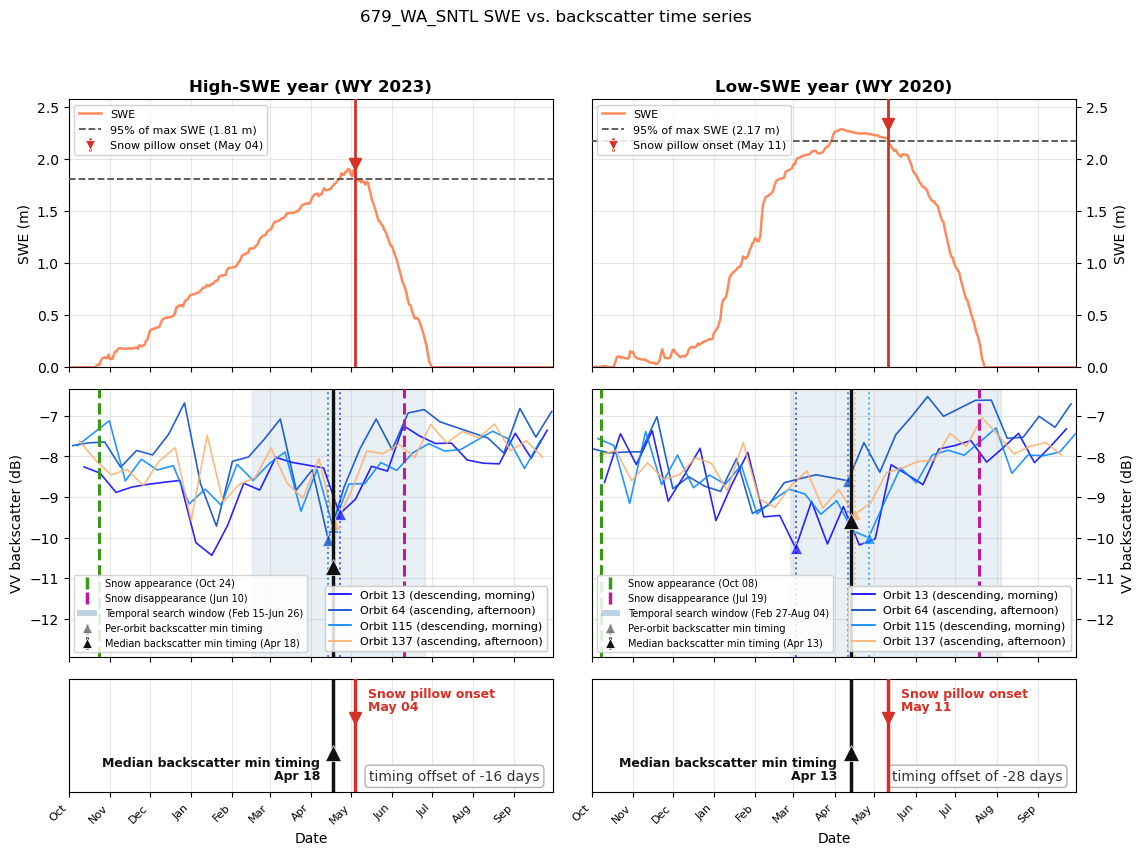

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.legend_handler import HandlerBase

# ── Colours ───────────────────────────────────────────────────────────────────
COL_FILTERED = "#fc8a5e"
COL_THRESH   = "#55514a"
COL_SP       = '#d73027'
COL_SAR      = '#111111'
COL_SAD      = "#389912"
COL_SDD      = "#C01A9C"
ORBIT_COLORS = ["#0400ff", "#0046c7", "#0084ff", '#fdae6b', '#9ecae1']

SDD_OFFSET = pd.Timedelta(days=16)

# ── Custom legend handler: vertical line + triangle ───────────────────────────
class HandlerVLine(HandlerBase):
    """
    Renders a vertical line (with optional triangle marker) in the legend key.
    Line is drawn at full key height so it's clearly visible behind the marker.
    """
    def __init__(self, color, lw=0.5, ls='-', alpha=1.0,
                 marker=None, ms=5, marker_alpha=1.0, marker_pos=0.35):
        self._color        = color
        self._lw           = lw
        self._ls           = ls
        self._alpha        = alpha
        self._marker       = marker
        self._ms           = ms
        self._marker_alpha = marker_alpha
        self._marker_pos   = marker_pos
        super().__init__()

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        cx = xdescent + width / 2.0
        artists = []
        # Triangle drawn FIRST so the line renders on top of it


        # Line drawn SECOND so it sits on top of the triangle
# White backing line (drawn between triangle and colored line)
        vline_bg = plt.Line2D(
            [cx, cx], [ydescent - 2, ydescent + height + 2],
            color='white', linewidth=self._lw + 1.0, linestyle=self._ls,
            solid_capstyle='butt', transform=trans,
        )
        artists.append(vline_bg)
        # Colored line on top
        vline = plt.Line2D(
            [cx, cx], [ydescent - 2, ydescent + height + 2],
            color=self._color, linewidth=self._lw, linestyle=self._ls,
            alpha=self._alpha, solid_capstyle='butt', transform=trans,
        )
        artists.append(vline)
        
        if self._marker:
            my = ydescent + height * self._marker_pos        
            tri = plt.Line2D(
                [cx], [my], marker=self._marker,
                color=self._color, markersize=7,   # fixed size for all entries
                alpha=self._marker_alpha, linestyle='None',
                markeredgecolor='white', markeredgewidth=0.6,
                transform=trans,
            )
            artists.append(tri)
            
        return artists


def vline_entry(label, color, lw=1.5, ls='-', alpha=1.0,
                marker=None, ms=5, marker_alpha=1.0, marker_pos=0.35):
    proxy = mlines.Line2D([], [], color=color, lw=lw, linestyle=ls,
                          alpha=alpha, label=label)
    handler = HandlerVLine(color=color, lw=lw, ls=ls, alpha=alpha,
                           marker=marker, ms=ms,
                           marker_alpha=marker_alpha, marker_pos=marker_pos)
    return proxy, handler


# ── MODIS seasonal snow mask ──────────────────────────────────────────────────
bbox_gdf = station_gdf
seasonal_snow_mask = xr.open_zarr(
    config.snow_phenology_store, consolidated=True, decode_coords='all'
)
seasonal_snow_mask_clip_ds = seasonal_snow_mask.rio.clip_box(
    *bbox_gdf.total_bounds, crs=bbox_gdf.crs
)

MODIS_SDD_DOWY = seasonal_snow_mask_clip_ds['SDD_DOWY'].median(dim=['x', 'y']).values
MODIS_SAD_DOWY = seasonal_snow_mask_clip_ds['SAD_DOWY'].median(dim=['x', 'y']).values

WY_all    = seasonal_snow_mask_clip_ds['SDD_DOWY'].water_year.values
WY_starts = [pd.Timestamp(year=int(y) - 1, month=10, day=1) for y in WY_all]
SAD_dates = {int(WY_all[i]): WY_starts[i] + pd.Timedelta(MODIS_SAD_DOWY[i] - 1, 'days')
             for i in range(len(WY_all))}
SDD_dates = {int(WY_all[i]): WY_starts[i] + pd.Timedelta(MODIS_SDD_DOWY[i] - 1, 'days')
             for i in range(len(WY_all))}

# ── SAR helpers ───────────────────────────────────────────────────────────────
def get_sar_for_wy(vv_dB, wy):
    start = pd.Timestamp(f'{wy-1}-10-01')
    end   = pd.Timestamp(f'{wy}-09-30')
    mask  = (pd.to_datetime(vv_dB.time.values) >= start) & \
            (pd.to_datetime(vv_dB.time.values) <= end)
    return vv_dB.isel(time=mask)


def compute_sar_onset(vv_wy_da, sad_date, sdd_date):
    if sad_date is None or sdd_date is None:
        return None, np.nan, []

    sdd_adjusted  = sdd_date + SDD_OFFSET
    snow_midpoint = sad_date + (sdd_date - sad_date) / 2
    times         = pd.to_datetime(vv_wy_da.time.values)
    vals          = vv_wy_da.values
    orbit_results = []

    if 'sat:relative_orbit' in vv_wy_da.coords:
        orbits = np.unique(vv_wy_da['sat:relative_orbit'].values)
        for i, rel_orbit in enumerate(orbits):
            mask_orbit  = (vv_wy_da['sat:relative_orbit'] == rel_orbit).values
            sub_times   = times[mask_orbit]
            sub_vals    = vals[mask_orbit]
            window_mask = (sub_times >= snow_midpoint) & (sub_times <= sdd_adjusted)
            if not np.any(window_mask) or np.all(np.isnan(sub_vals[window_mask])):
                continue
            w_times = sub_times[window_mask]
            w_vals  = sub_vals[window_mask]
            min_idx = np.nanargmin(w_vals)
            orbit_results.append({
                'orbit': rel_orbit,
                'date':  w_times[min_idx],
                'dB':    w_vals[min_idx],
                'color': ORBIT_COLORS[i % len(ORBIT_COLORS)],
            })
    else:
        window_mask = (times >= snow_midpoint) & (times <= sdd_adjusted)
        if np.any(window_mask) and not np.all(np.isnan(vals[window_mask])):
            w_times = times[window_mask]
            w_vals  = vals[window_mask]
            min_idx = np.nanargmin(w_vals)
            orbit_results.append({'orbit': 0, 'date': w_times[min_idx],
                                  'dB': w_vals[min_idx], 'color': ORBIT_COLORS[0]})

    if not orbit_results:
        return None, np.nan, []

    ordinals    = [d['date'].toordinal() for d in orbit_results]
    median_ord  = int(np.median(ordinals))
    median_date = pd.Timestamp.fromordinal(median_ord)
    closest     = min(orbit_results, key=lambda d: abs(d['date'].toordinal() - median_ord))
    return median_date, closest['dB'], orbit_results


# ── Build result dicts ────────────────────────────────────────────────────────
r_clear     = {}
r_ambiguous = {}

for r, wy in [(r_clear, clear_wy), (r_ambiguous, ambiguous_wy)]:
    r['wy']  = wy
    r['swe'] = get_swe_for_wy(filtered_swe, wy)
    r['vv']  = get_sar_for_wy(vv_dB, wy)
    r['sad'] = SAD_dates.get(wy)
    r['sdd'] = SDD_dates.get(wy)

    swe_vals  = r['swe'].values
    times_f   = pd.to_datetime(r['swe'].time.values)
    max_swe   = np.nanmax(swe_vals)
    threshold = 0.95 * max_swe
    above     = np.where(swe_vals >= threshold)[0]

    r['max_swe']   = max_swe
    r['threshold'] = threshold
    r['sp_onset']  = times_f[above[-1]] if len(above) else None

    r['sar_onset'], r['min_dB'], r['orbit_results'] = compute_sar_onset(
        r['vv'], r['sad'], r['sdd'])
    r['diff_days'] = (
        (r['sar_onset'] - r['sp_onset']).days
        if r['sp_onset'] is not None and r['sar_onset'] is not None else None
    )


# ── X-axis formatter ──────────────────────────────────────────────────────────
def apply_xaxis_fmt(ax, show_labels=True):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    if show_labels:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter(''))


# ── SWE panels ────────────────────────────────────────────────────────────────
def plot_swe_panel(ax, r, right=False):
    wy      = r['wy']
    xlim    = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))
    times_f = pd.to_datetime(r['swe'].time.values)

    ax.plot(times_f, r['swe'].values, color=COL_FILTERED, lw=1.8, zorder=2)
    ax.axhline(r['threshold'], color=COL_THRESH, lw=1.3, ls='--', zorder=3)

    if r['sp_onset'] is not None:
        ax.axvline(r['sp_onset'], color=COL_SP, lw=2.0, zorder=4)
        # Triangle hovers a fixed 0.05 m above the SWE peak
        marker_y = r['max_swe'] + 0.05
        ax.plot(r['sp_onset'], marker_y, 'v', color=COL_SP, ms=9, zorder=5)

    sp_proxy, sp_handler = vline_entry(
        label=f"Snow pillow onset "
              f"({r['sp_onset'].strftime('%b %d') if r['sp_onset'] else 'N/A'})",
        color=COL_SP, lw=2.0, marker='v', ms=4, marker_pos=0.50,
    )
    handles = [
        mlines.Line2D([], [], color=COL_FILTERED, lw=1.8, label='SWE'),
        mlines.Line2D([], [], color=COL_THRESH,   lw=1.3, ls='--',
                      label=f"95% of max SWE ({r['threshold']:.2f} m)"),
        sp_proxy,
    ]
    ax.legend(handles=handles, handler_map={sp_proxy: sp_handler},
              fontsize=8, loc='upper left', framealpha=0.85)
    ax.set_xlim(xlim)
    ax.set_ylim(bottom=0)
    ax.set_ylabel('SWE (m)', fontsize=10)
    ax.grid(True, alpha=0.3)
    apply_xaxis_fmt(ax, show_labels=False)

    if right:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()


# ── SAR panels ────────────────────────────────────────────────────────────────
def plot_sar_panel(ax, r, right=False):
    wy           = r['wy']
    xlim         = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))
    vv           = r['vv']
    sad          = r['sad']
    sdd = r['sdd']
    sdd_adjusted = r['sdd'] + SDD_OFFSET if r['sdd'] is not None else None

    # ── Orbit time-series → right legend ─────────────────────────────────────
    orbit_handles = []
    if 'sat:relative_orbit' in vv.coords:
        for i, rel_orbit in enumerate(np.unique(vv['sat:relative_orbit'].values)):
            sub         = vv.isel(time=(vv['sat:relative_orbit'] == rel_orbit))
            orbit_state = sub['sat:orbit_state'].values[0]
            tod         = 'ascending, afternoon' if orbit_state == 'ascending' \
                          else 'descending, morning'
            color       = ORBIT_COLORS[i % len(ORBIT_COLORS)]
            ax.plot(pd.to_datetime(sub.time.values), sub.values,
                    color=color, lw=1.2, alpha=0.85, zorder=2)
            orbit_handles.append(mlines.Line2D([], [], color=color, lw=1.2,
                                               label=f'Orbit {rel_orbit} ({tod})'))
    else:
        ax.plot(pd.to_datetime(vv.time.values), vv.values,
                color=ORBIT_COLORS[0], lw=1.2, zorder=2)
        orbit_handles.append(mlines.Line2D([], [], color=ORBIT_COLORS[0],
                                           lw=1.2, label='VV backscatter'))

    leg_right = ax.legend(handles=orbit_handles, fontsize=8,
                          loc='lower right', framealpha=0.85)
    ax.add_artist(leg_right)

    # ── Per-orbit minima: dotted vlines + bigger triangles ───────────────────
    for orb in r['orbit_results']:
        ax.axvline(orb['date'], color=orb['color'], lw=1.4, ls=':',
                   alpha=0.65, zorder=3)
        ax.plot(orb['date'], orb['dB'], '^',
                color=orb['color'], ms=9, alpha=0.70, zorder=4,
                markeredgewidth=0.6, markeredgecolor='white')

    # ── Median minimum: bold black vline + larger triangle ────────────────────
    if r['sar_onset'] is not None:
        ax.axvline(r['sar_onset'], color=COL_SAR, lw=2.4, zorder=5)
        ax.plot(r['sar_onset'], r['min_dB'] - 1.0, '^',
                color=COL_SAR, ms=11, zorder=6,
                markeredgewidth=0.5, markeredgecolor='white')

    # ── Left legend: MODIS + search window + per-orbit + median ──────────────
    left_handles  = []
    left_handlers = {}

    if sad is not None:
        ax.axvline(sad, color=COL_SAD, lw=2.2, ls='--', zorder=3)
        p, h = vline_entry(f'Snow appearance ({sad.strftime("%b %d")})',
                           COL_SAD, lw=2.5, ls='--')
        left_handles.append(p); left_handlers[p] = h

    if sdd is not None:
        ax.axvline(sdd, color=COL_SDD, lw=2.2, ls='--', zorder=3)
        p, h = vline_entry(
            f'Snow disappearance ({sdd.strftime("%b %d")})',
            COL_SDD, lw=2.5, ls='--')
        left_handles.append(p); left_handlers[p] = h

    if sad is not None and sdd is not None:
        snow_midpoint = sad + (sdd - sad) / 2
        ax.axvspan(snow_midpoint, sdd_adjusted, color='steelblue', alpha=0.12, zorder=1)
        left_handles.append(mpatches.Patch(facecolor='steelblue', alpha=0.35,
                                           label=f'Temporal search window ({snow_midpoint.strftime("%b %d")}-{sdd_adjusted.strftime("%b %d")})'))

    # Per-orbit: dotted line, smaller centered triangle in legend
    p_orb, h_orb = vline_entry('Per-orbit backscatter min timing',
                                '#666666', lw=2.0, ls=':', alpha=0.75,
                                marker='^', ms=4, marker_alpha=0.8, marker_pos=0.50)
    left_handles.append(p_orb); left_handlers[p_orb] = h_orb

    # Median: bold black, smaller centered triangle in legend
    if r['sar_onset'] is not None:
        p_med, h_med = vline_entry(
            f"Median backscatter min timing ({r['sar_onset'].strftime('%b %d')})",
            COL_SAR, lw=2.0,
            marker='^', ms=6, marker_pos=0.50)
        left_handles.append(p_med); left_handlers[p_med] = h_med

    ax.legend(handles=left_handles, handler_map=left_handlers,
              fontsize=7, loc='lower left', framealpha=0.85)
    ax.add_artist(leg_right)

    ax.set_xlim(xlim)
    ax.set_ylabel('VV backscatter (dB)', fontsize=10)
    ax.grid(True, alpha=0.3)
    apply_xaxis_fmt(ax, show_labels=False)

    if right:
        ax.yaxis.set_label_position('right')
        ax.yaxis.tick_right()


# ── Timeline panels ───────────────────────────────────────────────────────────
def plot_timeline_panel(ax, r, right=False):
    wy   = r['wy']
    xlim = (pd.Timestamp(f'{wy-1}-10-01'), pd.Timestamp(f'{wy}-09-30'))

    ax.set_xlim(xlim)
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_ylabel('')

    y_sp  = 0.65
    y_sar = 0.35

    LABEL_OFFSET = pd.Timedelta(days=10)   # gap between vline and label text

    # horizontal guide lines intentionally omitted

    # ── Snow pillow onset: label RIGHT of the vline ───────────────────────────
    if r['sp_onset'] is not None:
        ax.axvline(r['sp_onset'], color=COL_SP, lw=2.5, zorder=4)
        ax.plot(r['sp_onset'], y_sp, 'v', color=COL_SP, ms=9, zorder=5)

        label_x = r['sp_onset'] + LABEL_OFFSET
        ax.text(label_x, y_sp + 0.16,
                'Snow pillow onset',
                ha='left', va='bottom', fontsize=9, color=COL_SP,
                fontweight='bold')
        ax.text(label_x, y_sp + 0.04,
                r['sp_onset'].strftime('%b %d'),
                ha='left', va='bottom', fontsize=9, color=COL_SP,
                fontweight='bold')

    # Per-orbit elements intentionally omitted from timeline panel

    # ── Median SAR onset: bold black vline + bigger triangle ──────────────────
    if r['sar_onset'] is not None:
        ax.axvline(r['sar_onset'], color=COL_SAR, lw=2.5, zorder=5)
        ax.plot(r['sar_onset'], y_sar, '^', color=COL_SAR, ms=11, zorder=6,
                markeredgewidth=0.5, markeredgecolor='white')

        # Label LEFT of the vline
        label_x = r['sar_onset'] - LABEL_OFFSET
        ax.text(label_x, y_sar - 0.03,
                'Median backscatter min timing',
                ha='right', va='top', fontsize=9, color=COL_SAR,
                fontweight='bold')
        ax.text(label_x, y_sar - 0.15,
                r['sar_onset'].strftime('%b %d'),
                ha='right', va='top', fontsize=9, color=COL_SAR,
                fontweight='bold')

    # ── Diff annotation arrow ─────────────────────────────────────────────────
    if r['sp_onset'] is not None and r['sar_onset'] is not None \
            and r['diff_days'] is not None:
        x1   = r['sp_onset']
        x2   = r['sar_onset']
        sign = '+' if r['diff_days'] >= 0 else ''
        # ax.annotate('', xy=(x2, 0.5), xytext=(x1, 0.5),
        #             arrowprops=dict(arrowstyle='<->', color='#555555',
        #                            lw=1.6, mutation_scale=13))

        # Text box: bottom-right corner of the panel
        box_x = xlim[1] - pd.Timedelta(days=10)
        ax.text(box_x, 0.08,
                f"timing offset of {r['diff_days']} days",
                ha='right', va='bottom', fontsize=10, color='#333333',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='#aaaaaa', alpha=0.9))

    apply_xaxis_fmt(ax, show_labels=True)
    ax.set_xlabel('Date', fontsize=10)

    if right:
        ax.yaxis.set_label_position('right')


# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))

gs = gridspec.GridSpec(
    nrows=3, ncols=2,
    figure=fig,
    hspace=0.10, wspace=0.08,
    height_ratios=[2.0, 2.0, 0.85]
)

ax_swe_c = fig.add_subplot(gs[0, 0])
ax_swe_a = fig.add_subplot(gs[0, 1])
ax_sar_c = fig.add_subplot(gs[1, 0])
ax_sar_a = fig.add_subplot(gs[1, 1])
ax_tl_c  = fig.add_subplot(gs[2, 0])
ax_tl_a  = fig.add_subplot(gs[2, 1])

# ── Plot all panels ───────────────────────────────────────────────────────────
plot_swe_panel(ax_swe_c, r_clear,     right=False)
plot_swe_panel(ax_swe_a, r_ambiguous, right=True)

swe_ymax = max(ax_swe_c.get_ylim()[1], ax_swe_a.get_ylim()[1])
# Give a little headroom above peak SWE for the triangle marker
ax_swe_c.set_ylim(0, swe_ymax + 0.12)
ax_swe_a.set_ylim(0, swe_ymax + 0.12)

plot_sar_panel(ax_sar_c, r_clear,     right=False)
plot_sar_panel(ax_sar_a, r_ambiguous, right=True)

sar_ymin = min(ax_sar_c.get_ylim()[0], ax_sar_a.get_ylim()[0]) - 2
sar_ymax = max(ax_sar_c.get_ylim()[1], ax_sar_a.get_ylim()[1])
ax_sar_c.set_ylim(sar_ymin, sar_ymax)
ax_sar_a.set_ylim(sar_ymin, sar_ymax)

plot_timeline_panel(ax_tl_c, r_clear,     right=False)
plot_timeline_panel(ax_tl_a, r_ambiguous, right=True)

ax_swe_c.set_title(f'High-SWE year (WY {clear_wy})',    fontsize=12, fontweight='bold')
ax_swe_a.set_title(f'Low-SWE year (WY {ambiguous_wy})', fontsize=12, fontweight='bold')

ax_swe_c.set_ylabel('SWE (m)', fontsize=10)
ax_sar_c.set_ylabel('VV backscatter (dB)', fontsize=10)

fig.suptitle(f'{station_code} SWE vs. backscatter time series')

fig.savefig(FIGURE_DIR / f'high_swe_low_swe_backscatter_comparison_{station_code}_{clear_wy}_{ambiguous_wy}.png', dpi=350, bbox_inches='tight', facecolor='white') # manuscript figure A1
#fig.savefig('figures/high_swe_low_swe_comparison_846.png', dpi=350, bbox_inches='tight', facecolor='white')